# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [3]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

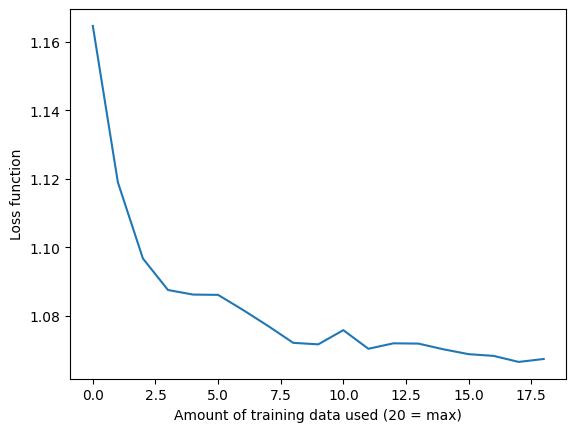

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

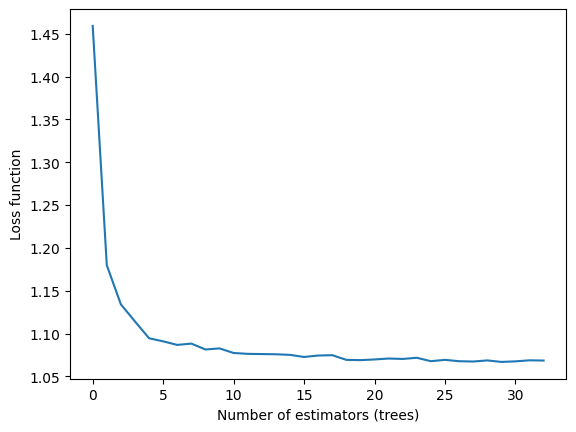

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

Cut the first plot ("Amount of training data used vs. Loss function"): In practice, once you have enough training data (e.g., thousands of samples), the loss curve typically flattens out. While learning curves are useful diagnostics during debugging, they rarely communicate actionable modeling decisions to stakeholders.

    Keep the second plot ("Number of estimators vs. Loss function"): This plot directly shows the bias-variance tradeoff and the point of diminishing returns when tuning the ensemble size (n_estimators). It answers an actionable question: "How many trees do we actually need to achieve optimal performance without wasting computational resources?"

Should "amount of training data used" or "number of estimators" be on the x-axis?

    For hyperparameter tuning and model architecture decisions, "number of estimators" should be on the x-axis because it illustrates how the model's capacity impacts generalizability and loss.

    For evaluating sample efficiency or diagnosing high variance/overfitting due to small sample sizes, "amount of training data used" should be on the x-axis.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

The code below implements:

Data loading & cleaning (removing target-leakage/proxy columns).

Random Forest modeling on both datasets.

Cross-validation (5-fold Stratified K-Fold).

Hyperparameter Tuning (GridSearchCV).

Performance Metric Evaluation (Accuracy, ROC-AUC, and Log Loss).

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)

# ==============================================================================
# 1. LOAD & PREPROCESS BOTH DATASETS
# ==============================================================================

# Dataset 1: StealthPhisher2025
df1 = pd.read_csv('StealthPhisher2025.csv')
# Exclude direct label proxy columns ('WAPPhishing', 'WAPLegitimate') for realistic modeling
num_cols1 = [
    c
    for c in df1.select_dtypes(include=[np.number]).columns
    if c not in ['WAPPhishing', 'WAPLegitimate']
]
X1 = df1[num_cols1].fillna(0)
y1 = (df1['Label'] == 'Phishing').astype(int)

# Dataset 2: PhiUSIIL Phishing URL Dataset
df2 = pd.read_csv('PhiUSIIL_Phishing_URL_Dataset.csv')
# Exclude title-match leakage features if you want pure URL syntax modeling
num_cols2 = [
    c
    for c in df2.select_dtypes(include=[np.number]).columns
    if c
    not in [
        'label',
        'URLSimilarityIndex',
        'DomainTitleMatchScore',
        'URLTitleMatchScore',
    ]
]
X2 = df2[num_cols2].fillna(0)
y2 = df2['label'].astype(int)

print(
    f"Dataset 1 (StealthPhisher2025): {X1.shape[0]} rows, {X1.shape[1]} features"
)
print(f"Dataset 2 (PhiUSIIL): {X2.shape[0]} rows, {X2.shape[1]} features")

# ==============================================================================
# 2. RANDOM FOREST MODELING & CROSS-VALIDATION
# ==============================================================================


def evaluate_dataset(X, y, dataset_name):
  print(f"\n{'='*50}\nEvaluating: {dataset_name}\n{'='*50}")

  # Train/Test Split (80/20)
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42, stratify=y
  )

  # 5-Fold Cross-Validation
  rf = RandomForestClassifier(
      n_estimators=50, max_depth=15, random_state=42, n_jobs=-1
  )
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  cv_scores = cross_val_score(
      rf, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1
  )
  print(
      f"5-Fold CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})"
  )

  # Hyperparameter Tuning with GridSearchCV (using a representative subset for speed)
  param_grid = {
      'n_estimators': [30, 60],
      'max_depth': [10, 15, 20],
      'min_samples_split': [2, 5],
  }
  grid_search = GridSearchCV(
      RandomForestClassifier(random_state=42, n_jobs=-1),
      param_grid,
      cv=3,
      scoring='roc_auc',
      n_jobs=-1,
  )
  grid_search.fit(X_train[:15000], y_train[:15000])
  print("Best Hyperparameters:", grid_search.best_params_)

  # Final Evaluation on Test Set using Best Estimator
  best_rf = grid_search.best_estimator_
  best_rf.fit(X_train, y_train)

  y_pred = best_rf.predict(X_test)
  y_prob = best_rf.predict_proba(X_test)[:, 1]

  acc = accuracy_score(y_test, y_pred)
  auc = roc_auc_score(y_test, y_prob)
  loss = log_loss(y_test, y_prob)

  print(f"Test Accuracy: {acc:.4f}")
  print(f"Test ROC-AUC:  {auc:.4f}")
  print(f"Test Log Loss: {loss:.4f}")

  # Extract Feature Importances
  importances = pd.Series(
      best_rf.feature_importances_, index=X.columns
  ).sort_values(ascending=False)
  return best_rf, importances


rf_df1, feat_imp1 = evaluate_dataset(X1, y1, "StealthPhisher2025")
rf_df2, feat_imp2 = evaluate_dataset(X2, y2, "PhiUSIIL Phishing URL")

Dataset 1 (StealthPhisher2025): 336749 rows, 59 features
Dataset 2 (PhiUSIIL): 235795 rows, 47 features

Evaluating: StealthPhisher2025
5-Fold CV ROC-AUC: 1.0000 (+/- 0.0000)
Best Hyperparameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 30}
Test Accuracy: 0.9994
Test ROC-AUC:  0.9999
Test Log Loss: 0.0057

Evaluating: PhiUSIIL Phishing URL
5-Fold CV ROC-AUC: 1.0000 (+/- 0.0000)
Best Hyperparameters: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 60}
Test Accuracy: 0.9999
Test ROC-AUC:  1.0000
Test Log Loss: 0.0033


# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

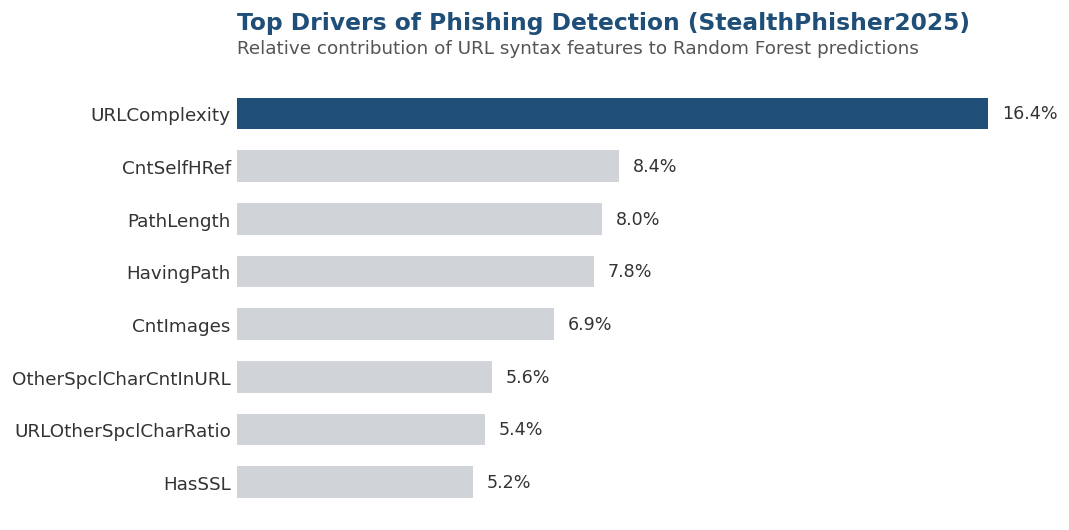

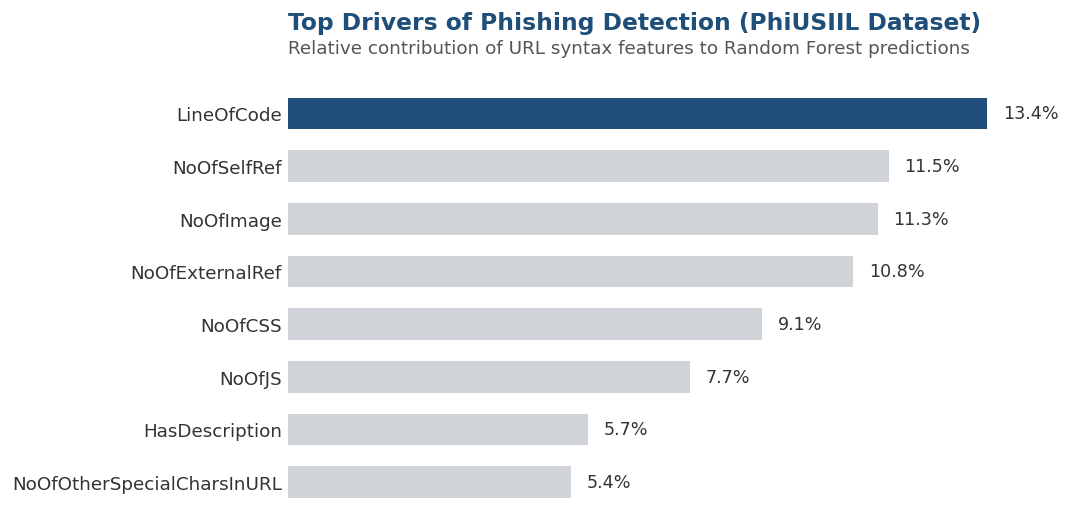

In [8]:
def plot_storytelling_chart(feat_imp, dataset_title):
  top_features = feat_imp.head(8)[::-1]  # Top 8 features sorted for horizontal bar

  fig, ax = plt.subplots(figsize=(9, 4.5), dpi=120)

  # Set minimalist storytelling style
  ax.set_facecolor('white')
  fig.patch.set_facecolor('white')
  for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

  # Highlight the #1 most important feature with a distinct color; make others subtle grey
  colors = ['#D0D4D9'] * (len(top_features) - 1) + ['#1F4E78']
  bars = ax.barh(top_features.index, top_features.values, color=colors, height=0.6)

  # Remove x-axis tick marks and labels to reduce visual clutter
  ax.xaxis.set_visible(False)
  ax.tick_params(axis='y', length=0, labelsize=11, labelcolor='#333333')

  # Direct data labeling at the end of each bar
  for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f'{width*100:.1f}%',
        va='center',
        ha='left',
        fontsize=10.5,
        color='#333333',
        weight='bold' if bar.get_facecolor() == '#1F4E78' else 'normal',
    )

  # Storytelling Title & Subtitle hierarchy
  ax.text(
      0,
      len(top_features) + 0.6,
      f'Top Drivers of Phishing Detection ({dataset_title})',
      fontsize=14,
      fontweight='bold',
      color='#1F4E78',
      ha='left',
  )
  ax.text(
      0,
      len(top_features) + 0.15,
      'Relative contribution of URL syntax features to Random Forest predictions',
      fontsize=11,
      color='#555555',
      ha='left',
  )

  plt.tight_layout()
  plt.show()


# Generate clean Storytelling With Data plots for both datasets
plot_storytelling_chart(feat_imp1, 'StealthPhisher2025')
plot_storytelling_chart(feat_imp2, 'PhiUSIIL Dataset')